In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil
import os

drive_dataset_path = "/content/drive/MyDrive/Dataset/Dataset"
local_dataset_path = "/content/Dataset"

if not os.path.exists(local_dataset_path):
    shutil.copytree(drive_dataset_path, local_dataset_path)

print("✅ Dataset copied to local path")

✅ Dataset copied to local path


In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

In [ ]:
IMAGE_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
full_dataset = datasets.ImageFolder(local_dataset_path, transform=train_transform)

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

# Validation & Test use normal transform
val_dataset.dataset.transform = val_test_transform
test_dataset.dataset.transform = val_test_transform

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 4426
Val: 948
Test: 949


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 5)
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
checkpoint_path = "/content/drive/MyDrive/best_resnet50_finetuned.pth"

checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint)

model.eval()

print("✅ ResNet50 loaded successfully")

✅ ResNet50 loaded successfully


In [ ]:
def compute_accuracy(model, loader):
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return accuracy_score(all_labels, all_preds)

train_acc = compute_accuracy(model, train_loader)
val_acc = compute_accuracy(model, val_loader)
test_acc = compute_accuracy(model, test_loader)

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.9959331224582015
Validation Accuracy: 0.9926160337552743
Test Accuracy: 0.9968387776606955


In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 82.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 18.5 MB/s eta 0:00:00
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=3e43e1257a86d48ead4a6b0f578739a3a1c8151ada6e5e4afb2c59bc8514e26f
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
from pytorch_grad_cam import GradCAMPlusPlus, ScoreCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import cv2

100%|██████████| 128/128 [02:23<00:00,  1.12s/it]


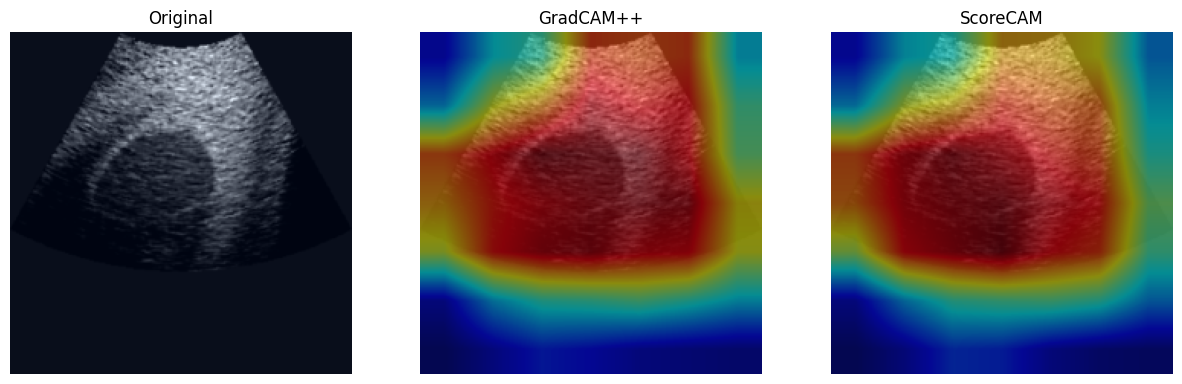

In [ ]:
target_layer = model.layer4[-1]

gradcam_pp = GradCAMPlusPlus(model=model, target_layers=[target_layer])
scorecam = ScoreCAM(model=model, target_layers=[target_layer])

images, labels = next(iter(test_loader))
input_tensor = images[0].unsqueeze(0).to(device)

# GradCAM++
grayscale_cam_pp = gradcam_pp(input_tensor=input_tensor)[0]

# ScoreCAM
grayscale_cam_sc = scorecam(input_tensor=input_tensor)[0]

# Convert image to numpy
img = images[0].permute(1,2,0).numpy()
img = (img - img.min()) / (img.max() - img.min())

cam_pp_image = show_cam_on_image(img, grayscale_cam_pp, use_rgb=True)
cam_sc_image = show_cam_on_image(img, grayscale_cam_sc, use_rgb=True)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("GradCAM++")
plt.imshow(cam_pp_image)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("ScoreCAM")
plt.imshow(cam_sc_image)
plt.axis("off")

plt.show()

In [ ]:
from pytorch_grad_cam import GradCAMPlusPlus, ScoreCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import matplotlib.pyplot as plt

target_layer = model.layer4[-1]

gradcam_pp = GradCAMPlusPlus(model=model, target_layers=[target_layer])
scorecam = ScoreCAM(model=model, target_layers=[target_layer])

class_names = full_dataset.classes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

100%|██████████| 128/128 [02:18<00:00,  1.08s/it]


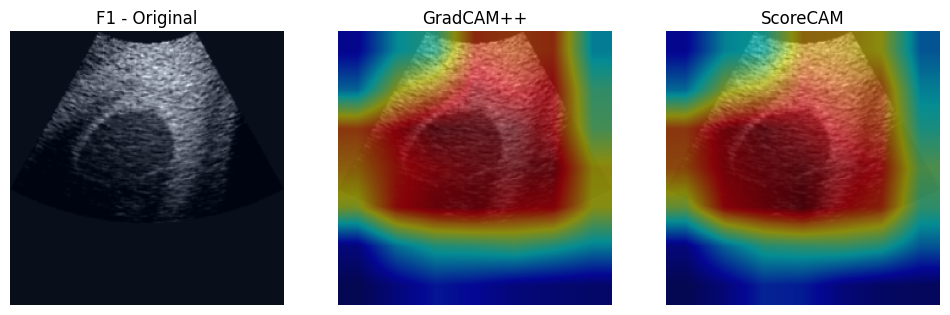

100%|██████████| 128/128 [01:46<00:00,  1.20it/s]


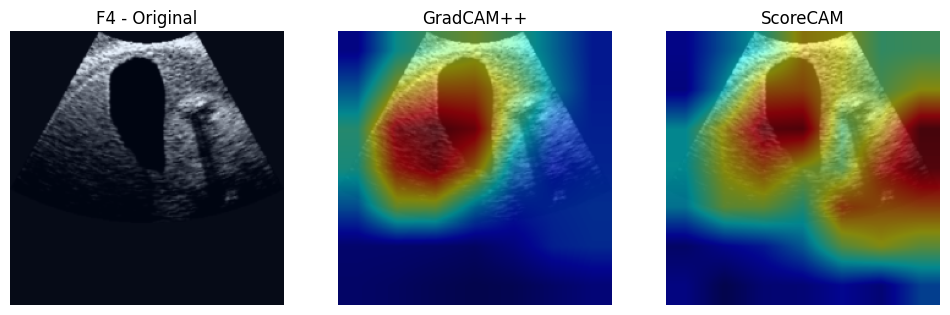

100%|██████████| 128/128 [01:59<00:00,  1.07it/s]


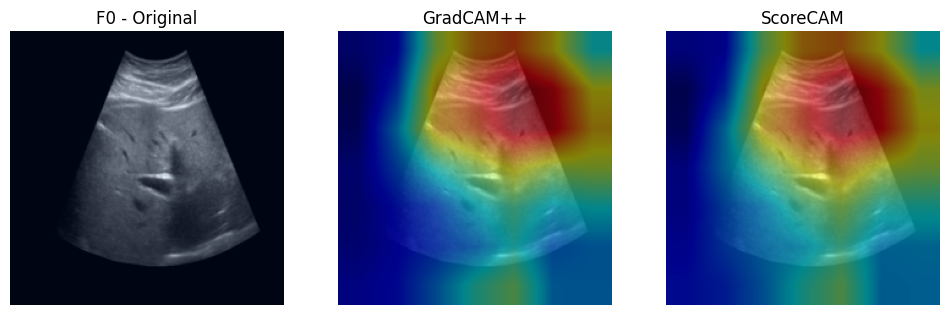

100%|██████████| 128/128 [01:47<00:00,  1.19it/s]


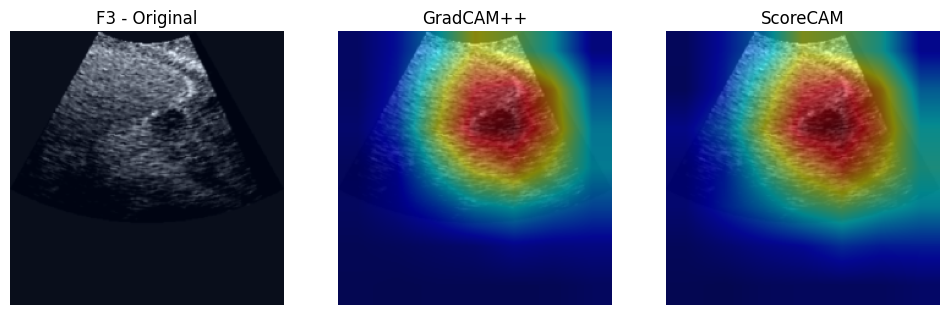

100%|██████████| 128/128 [01:50<00:00,  1.16it/s]


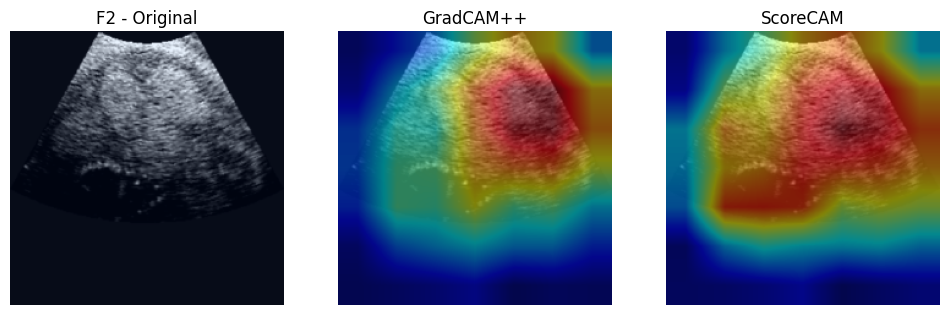

In [ ]:
found_classes = set()

for images, labels in test_loader:
    images = images.to(device)
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

    for i in range(len(images)):
        true_label = labels[i].item()
        pred_label = preds[i].item()

        # Only show correctly classified examples
        if true_label == pred_label and true_label not in found_classes:

            input_tensor = images[i].unsqueeze(0)

            # GradCAM++
            cam_pp = gradcam_pp(input_tensor=input_tensor)[0]

            # ScoreCAM
            cam_sc = scorecam(input_tensor=input_tensor)[0]

            # Convert image
            img = images[i].cpu().permute(1,2,0).numpy()
            img = (img - img.min()) / (img.max() - img.min())

            cam_pp_image = show_cam_on_image(img, cam_pp, use_rgb=True)
            cam_sc_image = show_cam_on_image(img, cam_sc, use_rgb=True)

            # Plot
            plt.figure(figsize=(12,4))

            plt.subplot(1,3,1)
            plt.title(f"{class_names[true_label]} - Original")
            plt.imshow(img)
            plt.axis("off")

            plt.subplot(1,3,2)
            plt.title("GradCAM++")
            plt.imshow(cam_pp_image)
            plt.axis("off")

            plt.subplot(1,3,3)
            plt.title("ScoreCAM")
            plt.imshow(cam_sc_image)
            plt.axis("off")

            plt.show()

            found_classes.add(true_label)

    if len(found_classes) == len(class_names):
        break

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import torch.nn.functional as F
import numpy as np

model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

In [ ]:
# Accuracy
accuracy = accuracy_score(all_labels, all_preds)

# Precision, Recall, F1 (Macro & Weighted)
precision_macro = precision_score(all_labels, all_preds, average='macro')
recall_macro = recall_score(all_labels, all_preds, average='macro')
f1_macro = f1_score(all_labels, all_preds, average='macro')

precision_weighted = precision_score(all_labels, all_preds, average='weighted')
recall_weighted = recall_score(all_labels, all_preds, average='weighted')
f1_weighted = f1_score(all_labels, all_preds, average='weighted')

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

# ROC-AUC (One-vs-Rest)
roc_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')

print("===== Evaluation Metrics =====")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (Macro): {precision_macro:.4f}")
print(f"Recall (Macro): {recall_macro:.4f}")
print(f"F1 Score (Macro): {f1_macro:.4f}")
print(f"Precision (Weighted): {precision_weighted:.4f}")
print(f"Recall (Weighted): {recall_weighted:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")
print(f"ROC-AUC (OvR): {roc_auc:.4f}")

print("\n===== Classification Report =====")
print(classification_report(all_labels, all_preds, target_names=full_dataset.classes))

print("\n===== Confusion Matrix =====")
print(cm)

===== Evaluation Metrics =====
Accuracy: 0.9968
Precision (Macro): 0.9955
Recall (Macro): 0.9945
F1 Score (Macro): 0.9950
Precision (Weighted): 0.9968
Recall (Weighted): 0.9968
F1 Score (Weighted): 0.9968
ROC-AUC (OvR): 1.0000

===== Classification Report =====
              precision    recall  f1-score   support

          F0       1.00      1.00      1.00       327
          F1       1.00      1.00      1.00       147
          F2       0.99      0.99      0.99       105
          F3       0.99      0.98      0.99       111
          F4       1.00      1.00      1.00       259

    accuracy                           1.00       949
   macro avg       1.00      0.99      0.99       949
weighted avg       1.00      1.00      1.00       949


===== Confusion Matrix =====
[[327   0   0   0   0]
 [  0 147   0   0   0]
 [  0   0 104   1   0]
 [  0   0   1 109   1]
 [  0   0   0   0 259]]


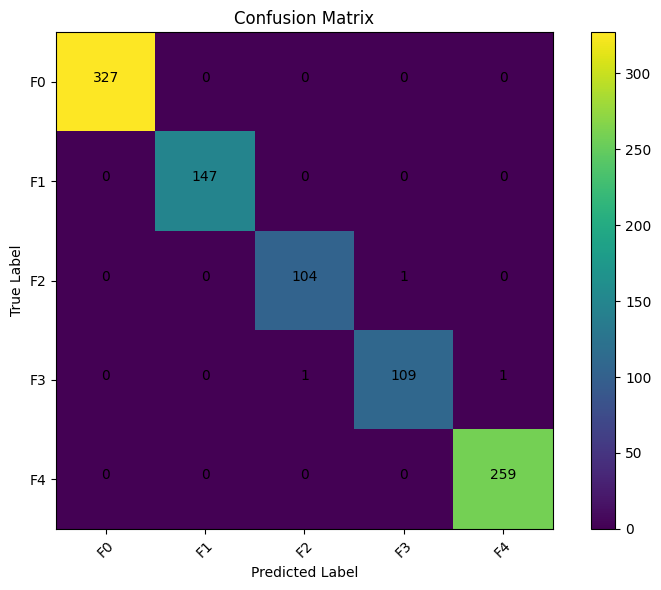

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

class_names = full_dataset.classes

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

# Add numbers inside matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()